<a href="https://colab.research.google.com/github/sanskriti-0312/Machine_Learning_Assignments/blob/main/ML_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 30)
Target Shape: (569,)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']

Class Distribution:
Benign    (0): 357
Malignant (1): 212

Training Data Shape: (455, 30)
Testing Data Shape : (114, 30)

Feature scaling completed.

LOGISTIC REGRESSION FROM SCRATCH
Logistic Regression training completed.

PERCEPTRON FROM SCRATCH
Perceptron training completed.

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.9824561403508771
Pr

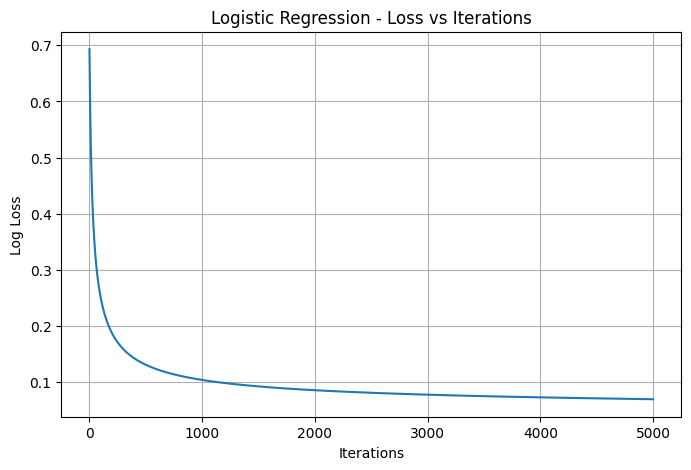

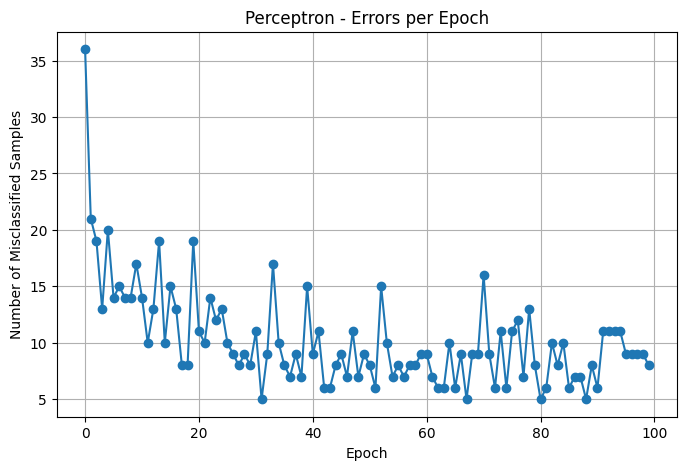


DECISION BOUNDARY USING TWO FEATURES


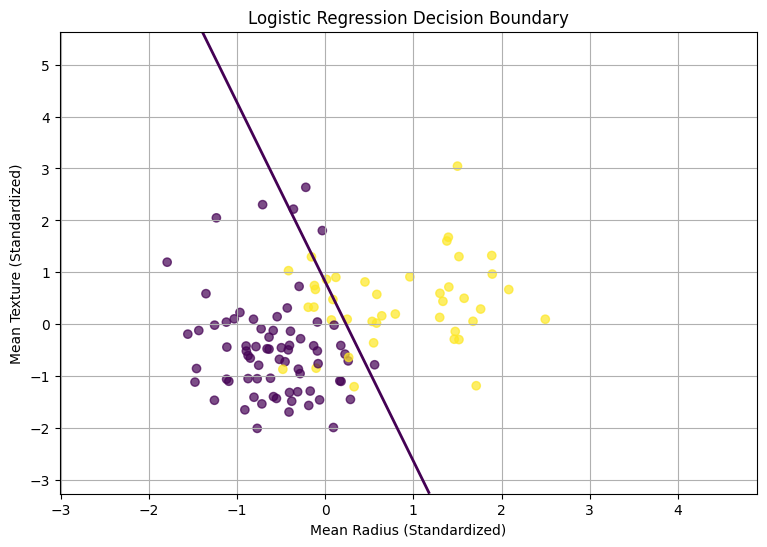

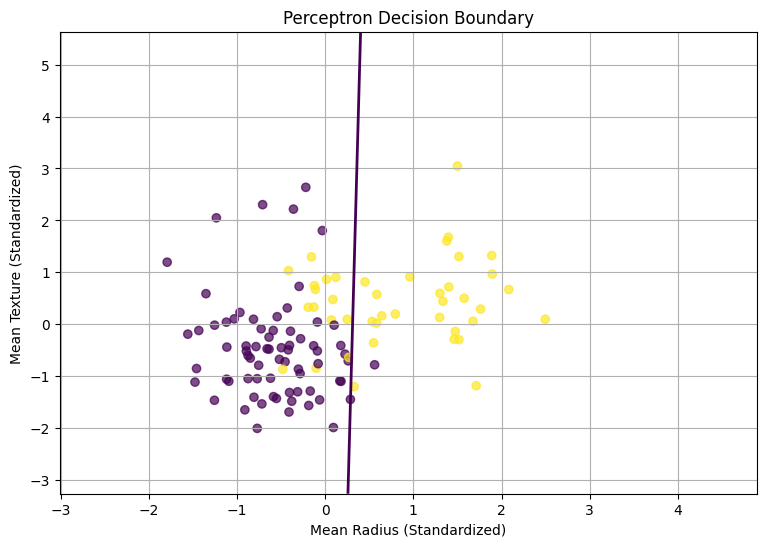


FINAL RESULT

               Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.982456       1.00 0.952381  0.975610
         Perceptron  0.947368       0.95 0.904762  0.926829

Experiment completed successfully.


In [1]:
# ============================================================
# LAB EXPERIMENT 2
# LOGISTIC REGRESSION AND PERCEPTRON
# ============================================================

# ------------------------------------------------------------
# 1. Import Required Libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. LOAD BREAST CANCER DATASET
# ============================================================

data = load_breast_cancer()

X = data.data
y_original = data.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y_original.shape)

print("\nFeature Names:")
print(data.feature_names)

print("\nTarget Names:")
print(data.target_names)


# ------------------------------------------------------------
# Convert target:
#
# sklearn:
# 0 = malignant
# 1 = benign
#
# For this experiment, we use:
# 1 = malignant
# 0 = benign
#
# This makes "malignant" the positive class.
# ------------------------------------------------------------

y = 1 - y_original

print("\nClass Distribution:")
print("Benign    (0):", np.sum(y == 0))
print("Malignant (1):", np.sum(y == 1))


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)


# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ============================================================
# 5. LOGISTIC REGRESSION FROM SCRATCH
#    USING GRADIENT DESCENT
# ============================================================

print("\n==============================================")
print("LOGISTIC REGRESSION FROM SCRATCH")
print("==============================================")


# ------------------------------------------------------------
# Sigmoid Function
# ------------------------------------------------------------

def sigmoid(z):

    # Clip z to avoid numerical overflow
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


# ------------------------------------------------------------
# Logistic Regression using Gradient Descent
# ------------------------------------------------------------

def logistic_regression_gd(
    X,
    y,
    learning_rate=0.01,
    iterations=5000
):

    # Number of samples and features
    m, n = X.shape

    # Initialize weights and bias
    weights = np.zeros(n)
    bias = 0.0

    # Store loss values
    loss_history = []

    # Gradient Descent
    for i in range(iterations):

        # Linear combination
        z = np.dot(X, weights) + bias

        # Sigmoid activation
        y_prob = sigmoid(z)

        # Error
        error = y_prob - y

        # Gradients
        dw = (1 / m) * np.dot(X.T, error)
        db = (1 / m) * np.sum(error)

        # Update weights and bias
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

        # Binary Cross Entropy Loss
        epsilon = 1e-15

        y_prob_clipped = np.clip(
            y_prob,
            epsilon,
            1 - epsilon
        )

        loss = -np.mean(
            y * np.log(y_prob_clipped)
            +
            (1 - y) * np.log(1 - y_prob_clipped)
        )

        loss_history.append(loss)

    return weights, bias, loss_history


# ------------------------------------------------------------
# Train Logistic Regression
# ------------------------------------------------------------

log_weights, log_bias, loss_history = logistic_regression_gd(
    X_train_scaled,
    y_train,
    learning_rate=0.01,
    iterations=5000
)


# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def logistic_predict(X, weights, bias):

    # Calculate probability
    probabilities = sigmoid(
        np.dot(X, weights) + bias
    )

    # Convert probability to class
    predictions = (probabilities >= 0.5).astype(int)

    return predictions


# ------------------------------------------------------------
# Make predictions
# ------------------------------------------------------------

y_pred_logistic = logistic_predict(
    X_test_scaled,
    log_weights,
    log_bias
)


print("Logistic Regression training completed.")


# ============================================================
# 6. PERCEPTRON FROM SCRATCH
# ============================================================

print("\n==============================================")
print("PERCEPTRON FROM SCRATCH")
print("==============================================")


# ------------------------------------------------------------
# Perceptron Learning Algorithm
#
# Perceptron works with:
# -1 for negative class
# +1 for positive class
# ------------------------------------------------------------

def perceptron_train(
    X,
    y,
    learning_rate=0.01,
    epochs=100
):

    # Convert:
    # 0 -> -1
    # 1 -> +1

    y_perceptron = np.where(
        y == 0,
        -1,
        1
    )

    # Number of samples and features
    m, n = X.shape

    # Initialize weights and bias
    weights = np.zeros(n)
    bias = 0.0

    errors_per_epoch = []

    # Training
    for epoch in range(epochs):

        errors = 0

        # Go through every training sample
        for i in range(m):

            # Calculate activation
            activation = (
                np.dot(X[i], weights)
                + bias
            )

            # Prediction
            prediction = 1 if activation >= 0 else -1

            # Perceptron update
            if prediction != y_perceptron[i]:

                weights = (
                    weights
                    + learning_rate
                    * y_perceptron[i]
                    * X[i]
                )

                bias = (
                    bias
                    + learning_rate
                    * y_perceptron[i]
                )

                errors += 1

        errors_per_epoch.append(errors)

        # Stop if no errors
        if errors == 0:
            break

    return weights, bias, errors_per_epoch


# ------------------------------------------------------------
# Perceptron Prediction
# ------------------------------------------------------------

def perceptron_predict(
    X,
    weights,
    bias
):

    activation = (
        np.dot(X, weights)
        + bias
    )

    predictions = np.where(
        activation >= 0,
        1,
        0
    )

    return predictions


# ------------------------------------------------------------
# Train Perceptron
# ------------------------------------------------------------

perceptron_weights, perceptron_bias, perceptron_errors = (
    perceptron_train(
        X_train_scaled,
        y_train,
        learning_rate=0.01,
        epochs=100
    )
)


# ------------------------------------------------------------
# Make predictions
# ------------------------------------------------------------

y_pred_perceptron = perceptron_predict(
    X_test_scaled,
    perceptron_weights,
    perceptron_bias
)

print("Perceptron training completed.")


# ============================================================
# 7. EVALUATE LOGISTIC REGRESSION
# ============================================================

print("\n==============================================")
print("LOGISTIC REGRESSION PERFORMANCE")
print("==============================================")


accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)


print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1-Score :", f1_logistic)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic
    )
)


# ============================================================
# 8. EVALUATE PERCEPTRON
# ============================================================

print("\n==============================================")
print("PERCEPTRON PERFORMANCE")
print("==============================================")


accuracy_perceptron = accuracy_score(
    y_test,
    y_pred_perceptron
)

precision_perceptron = precision_score(
    y_test,
    y_pred_perceptron,
    zero_division=0
)

recall_perceptron = recall_score(
    y_test,
    y_pred_perceptron,
    zero_division=0
)

f1_perceptron = f1_score(
    y_test,
    y_pred_perceptron,
    zero_division=0
)


print("Accuracy :", accuracy_perceptron)
print("Precision:", precision_perceptron)
print("Recall   :", recall_perceptron)
print("F1-Score :", f1_perceptron)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_perceptron
    )
)


# ============================================================
# 9. COMPARE BOTH MODELS
# ============================================================

print("\n==============================================")
print("MODEL COMPARISON")
print("==============================================")


results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Perceptron"
    ],

    "Accuracy": [
        accuracy_logistic,
        accuracy_perceptron
    ],

    "Precision": [
        precision_logistic,
        precision_perceptron
    ],

    "Recall": [
        recall_logistic,
        recall_perceptron
    ],

    "F1-Score": [
        f1_logistic,
        f1_perceptron
    ]
})


print(
    results.to_string(index=False)
)


# ============================================================
# 10. PLOT LOGISTIC REGRESSION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Iterations")
plt.ylabel("Log Loss")

plt.title(
    "Logistic Regression - Loss vs Iterations"
)

plt.grid(True)

plt.show()


# ============================================================
# 11. PLOT PERCEPTRON ERRORS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    perceptron_errors,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")

plt.title(
    "Perceptron - Errors per Epoch"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. DECISION BOUNDARY USING 2 FEATURES
# ============================================================

print("\n==============================================")
print("DECISION BOUNDARY USING TWO FEATURES")
print("==============================================")


# ------------------------------------------------------------
# Select two features
#
# Feature 0 = mean radius
# Feature 1 = mean texture
# ------------------------------------------------------------

feature_1 = 0
feature_2 = 1

X_two = X[:, [feature_1, feature_2]]


# ------------------------------------------------------------
# Split the two-feature dataset
# ------------------------------------------------------------

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_two,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Scale the two features
# ------------------------------------------------------------

scaler_2 = StandardScaler()

X2_train_scaled = scaler_2.fit_transform(X2_train)
X2_test_scaled = scaler_2.transform(X2_test)


# ============================================================
# 13. TRAIN LOGISTIC REGRESSION ON TWO FEATURES
# ============================================================

log_w_2, log_b_2, _ = logistic_regression_gd(
    X2_train_scaled,
    y2_train,
    learning_rate=0.01,
    iterations=5000
)


# ============================================================
# 14. TRAIN PERCEPTRON ON TWO FEATURES
# ============================================================

perc_w_2, perc_b_2, _ = perceptron_train(
    X2_train_scaled,
    y2_train,
    learning_rate=0.01,
    epochs=100
)


# ============================================================
# 15. CREATE MESH GRID
# ============================================================

x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


grid = np.c_[
    xx.ravel(),
    yy.ravel()
]


# ============================================================
# 16. LOGISTIC REGRESSION DECISION BOUNDARY
# ============================================================

log_prob_grid = sigmoid(
    np.dot(grid, log_w_2)
    + log_b_2
)

log_boundary = log_prob_grid.reshape(
    xx.shape
)


plt.figure(figsize=(9, 6))

# Data points
plt.scatter(
    X2_test_scaled[:, 0],
    X2_test_scaled[:, 1],
    c=y2_test,
    alpha=0.7
)

# Decision boundary
plt.contour(
    xx,
    yy,
    log_boundary,
    levels=[0.5],
    linewidths=2
)

plt.xlabel(
    "Mean Radius (Standardized)"
)

plt.ylabel(
    "Mean Texture (Standardized)"
)

plt.title(
    "Logistic Regression Decision Boundary"
)

plt.grid(True)

plt.show()


# ============================================================
# 17. PERCEPTRON DECISION BOUNDARY
# ============================================================

perc_activation_grid = (
    np.dot(grid, perc_w_2)
    + perc_b_2
)

perc_boundary = perc_activation_grid.reshape(
    xx.shape
)


plt.figure(figsize=(9, 6))

# Data points
plt.scatter(
    X2_test_scaled[:, 0],
    X2_test_scaled[:, 1],
    c=y2_test,
    alpha=0.7
)

# Decision boundary
plt.contour(
    xx,
    yy,
    perc_boundary,
    levels=[0],
    linewidths=2
)

plt.xlabel(
    "Mean Radius (Standardized)"
)

plt.ylabel(
    "Mean Texture (Standardized)"
)

plt.title(
    "Perceptron Decision Boundary"
)

plt.grid(True)

plt.show()


# ============================================================
# 18. DISPLAY FINAL RESULTS
# ============================================================

print("\n==============================================")
print("FINAL RESULT")
print("==============================================")

print("\n", results.to_string(index=False))

print("\nExperiment completed successfully.")